In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder,MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("cleaned_ai_adoption_data.csv")

In [3]:
y = df["ROI"]
X = df.drop(columns="ROI")

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
X_train.shape

(88080, 14)

In [6]:
y_train.shape

(88080,)

In [16]:
# column groups
ordinal_cols = ["company_size", "ai_adoption_stage"]
ordinal_indices = df.columns.get_indexer(ordinal_cols)

ordinal_categories = [
    ["Startup", "SME", "Enterprise"],
    ["none", "pilot", "partial", "full"]
]

nominal_cols = ["industry", "country", "ai_primary_tool"]
nominal_indices = df.columns.get_indexer(nominal_cols)

numerical_cols = [
    "annual_revenue_usd_millions",
    "ai_adoption_rate",
    "years_using_ai",
    "ai_maturity_score",
    "num_ai_tools_used",
    "ai_projects_active",
    "ai_budget_percentage",
    "ai_failure_rate",
    "ai_investment_per_employee"
]
numerical_indices = df.columns.get_indexer(numerical_cols)

In [17]:
df.columns.get_indexer(["company_size", "ai_adoption_stage"])

array([2, 5])

In [18]:
# encoding 
trf1 = ColumnTransformer(
    transformers=[
        ("ord", OrdinalEncoder(categories=ordinal_categories), ordinal_indices),
        ("nom", OneHotEncoder(drop="first", handle_unknown="ignore",sparse_output=False), nominal_indices)
    ], remainder='passthrough')

In [19]:
df.shape

(110101, 15)

In [20]:
# scaling 
trf2 = ColumnTransformer(
    transformers=[("num", StandardScaler(), numerical_indices)],remainder='passthrough')

In [21]:
# feature selection
from sklearn.feature_selection import SelectKBest,f_classif
trf3 = SelectKBest(score_func=f_classif,k=10)

In [22]:
# train the model
trf4 = RandomForestRegressor(n_estimators=200, random_state=42)

# Create Pipeline

In [23]:
pipe = make_pipeline(trf1,trf2,trf3,trf4)

In [24]:
from sklearn import set_config
set_config(transform_output="pandas")

In [16]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Startup',
                                                                              'SME',
                                                                              'Enterprise'],
                                                                             ['none',
                                                                              'pilot',
                                                                              'partial',
                                                                              'full']]),
                                                  array([2, 5])),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  array([0, 1, 8]))])),
                ('columntransformer-2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  array([ 3,  4,  6,  7,  9, 10, 11, 12, 13]))])),
                ('selectkbest', SelectKBest()),
                ('randomforestregressor',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [17]:
y_pred = pipe.predict(X_test)

In [18]:
r2_score = pipe.score(X_test, y_test)
print(f"R^2 Score: {r2_score:.4f}")

R^2 Score: 0.4324


In [19]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"On average, my predictions are off by: {mae}")

On average, my predictions are off by: 0.7288485942166021


In [22]:
avg_y = y_test.mean()
error_pct = (0.7288 / avg_y) * 100
print(f"Average error is {error_pct:.2f}% of the mean value.")

Average error is -334.51% of the mean value.


In [23]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
print("Baseline MAE:", mean_absolute_error(y_test, dummy.predict(X_test)))

Baseline MAE: 0.9824309606517758


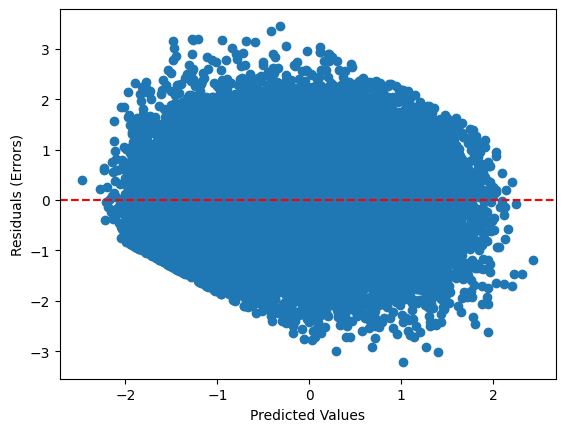

In [24]:
import matplotlib.pyplot as plt
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Errors)')
plt.show()

model is learning something.
A "Dummy" guess that just predicts the average every time is off by 0.98, 
while your model is off by 0.73. You have improved upon a "blind guess" by about 25%.

In [26]:
from xgboost import XGBRegressor

# Define the pipeline
pipe_xgb = Pipeline([
    ('pre1', trf1),
    ('pre2', trf2),
    ('selectkbest', trf3),
    ('xgb', XGBRegressor(random_state=42))
])

# Fit the pipeline
pipe_xgb.fit(X_train, y_train)

Pipeline(steps=[('pre1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  OrdinalEncoder(categories=[['Startup',
                                                                              'SME',
                                                                              'Enterprise'],
                                                                             ['none',
                                                                              'pilot',
                                                                              'partial',
                                                                              'full']]),
                                                  array([2, 5])),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  array([0, 1, 8]))])),
                ('pre2',
                 ColumnTransformer(remainder='passthrough',
                                   transfo...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [27]:
y_pred = pipe_xgb.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2:.4f}")

R^2 Score: 0.4421


In [33]:
# Hyperparameter tunning 

In [29]:
from sklearn.model_selection import GridSearchCV
# hallow trees + slow learning
param_grid = {
    'xgb__n_estimators': [500, 1000],
    'xgb__learning_rate': [0.01, 0.05],
    'xgb__max_depth': [3, 5],    
    'xgb__subsample': [0.8],
    'xgb__colsample_bytree': [0.8],
    'xgb__gamma': [0, 0.1]
}


# n_jobs=-1 uses all your CPU cores to speed up the process
grid_search = GridSearchCV(pipe_xgb, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('pre1',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ord',
                                                                         OrdinalEncoder(categories=[['Startup',
                                                                                                     'SME',
                                                                                                     'Enterprise'],
                                                                                                    ['none',
                                                                                                     'pilot',
                                                                                                     'partial',
                                                                                                     'full']]),
                                                                         array([2, 5])),
                                                                        ('nom',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         array([0, 1, 8]))])),
                                       ('pre2',
                                        ColumnTransformer(rem...
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgb__colsample_bytree': [0.8], 'xgb__gamma': [0, 0.1],
                         'xgb__learning_rate': [0.01, 0.05],
                         'xgb__max_depth': [3, 5],
                         'xgb__n_estimators': [500, 1000],
                         'xgb__subsample': [0.8]},
             scoring='r2', verbose=1)

In [30]:
best_pipe = grid_search.best_estimator_
y_pred = best_pipe.predict(X_test)

print("--- Final Results ---")
print(f"Best CV R2 Score: {grid_search.best_score_:.4f}")
print(f"Test R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

--- Final Results ---
Best CV R2 Score: 0.4599
Test R2 Score: 0.4553
Test MAE: 0.7153
Best Parameters: {'xgb__colsample_bytree': 0.8, 'xgb__gamma': 0, 'xgb__learning_rate': 0.01, 'xgb__max_depth': 3, 'xgb__n_estimators': 1000, 'xgb__subsample': 0.8}


In [32]:
import joblib

# Save the best pipeline to a file
joblib.dump(best_pipe, 'best_xgb_model.pkl')

# To use it later:
# loaded_model = joblib.load('best_xgb_model.pkl')

['best_xgb_model.pkl']

In [36]:
def predict_roi(input_dict):
    """
    input_dict example:
    {
        "ai_budget_percentage": 20,
        "ai_investment_per_employee": 5000,
        "num_ai_tools_used": 5,
        "ai_projects_active": 3,
        "ai_adoption_rate": 0.7,
        "ai_adoption_stage": "advanced",
        "ai_maturity_score": 8,
        "years_using_ai": 4,
        "ai_failure_rate": 0.2,
        "company_size": "SME",
        "industry": "Retail",
        "annual_revenue_usd_millions": 50
    }
    """
    input_df = pd.DataFrame([input_dict])
    prediction = best_pipe.predict(input_df)
    return prediction[0]

In [37]:
sample_input = {
    "company_size": "SME",
    "ai_adoption_stage": "pilot",
    "industry": "Retail",
    "country": "India",
    "ai_primary_tool": "ChatGPT",
    "annual_revenue_usd_millions": 50,
    "ai_adoption_rate": 0.6,
    "years_using_ai": 3,
    "ai_maturity_score": 7,
    "num_ai_tools_used": 4,
    "ai_projects_active": 2,
    "ai_budget_percentage": 15,
    "ai_failure_rate": 0.2,
    "ai_investment_per_employee": 4000
}

In [39]:
input_df = pd.DataFrame([sample_input])
prediction = best_pipe.predict(input_df)
print("Predicted ROI:", prediction[0])

Predicted ROI: 0.4804914


C:\Users\KHUSHI COMPUTERS\Desktop\jupyter projects\mynewv\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
pipeline = joblib.load("roi_pipeline.pkl")